# 02 Modeling Comparison

This notebook compares three machine learning models for Taipei housing price prediction:

1. Ridge Regression  
2. Decision Tree  
3. XGBoost  

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

X = df.drop(columns=["tprice"])
y = df["tprice"]

df.shape

(490, 22)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 2. Train Models

### 2.0 Data preprocessing

In [4]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

In [5]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [6]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

### 2.1 Ridge Regression

In [8]:
ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_scaled),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test)

ridge_grid.best_params_

{'model__alpha': 0.01}

### 2.2 Decision Tree

In [9]:
tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_params = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": [None, "sqrt", "log2"]
}

tree_grid = GridSearchCV(
    tree_pipeline,
    tree_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

tree_best = tree_grid.best_estimator_
tree_pred = tree_best.predict(X_test)

tree_grid.best_params_

{'model__max_depth': 10,
 'model__max_features': None,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5}

### 2.3 XGBoost

In [10]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_alpha": [0, 1],
    "model__reg_lambda": [1, 10],
    "model__min_child_weight": [1, 5]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
xgb_pred = xgb_best.predict(X_test)

xgb_grid.best_params_

{'model__colsample_bytree': 0.8,
 'model__learning_rate': 0.1,
 'model__max_depth': 3,
 'model__min_child_weight': 1,
 'model__n_estimators': 300,
 'model__reg_alpha': 0,
 'model__reg_lambda': 1,
 'model__subsample': 1.0}

## 3. Compare Results

### 3.1 Model evaluation

In [25]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = [
    evaluate_model("Ridge Regression", y_test, ridge_pred),
    evaluate_model("Decision Tree", y_test, tree_pred),
    evaluate_model("XGBoost", y_test, xgb_pred)
]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2", ascending=False)
results_df

,Model,MAE,RMSE,R2
2,XGBoost,571.359031,868.903690,0.933538
0,Ridge Regression,862.251675,1343.003353,0.841224
1,Decision Tree,969.802782,2340.016517,0.517976


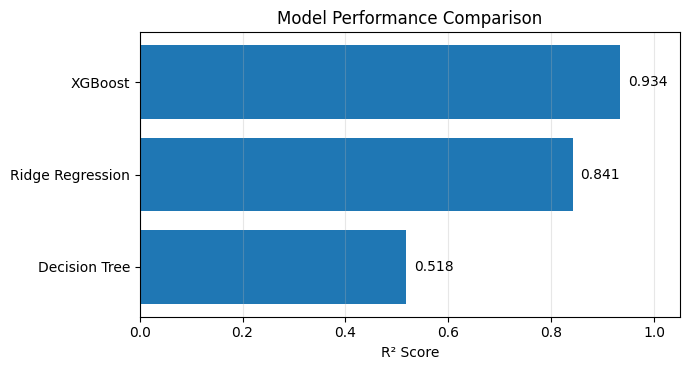

In [26]:
results_df_sorted = results_df.sort_values("R2", ascending=True)

plt.figure(figsize=(7, 3.8))
bars = plt.barh(results_df_sorted["Model"], results_df_sorted["R2"])

plt.xlabel("R² Score")
plt.title("Model Performance Comparison")
plt.xlim(0, 1.05)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

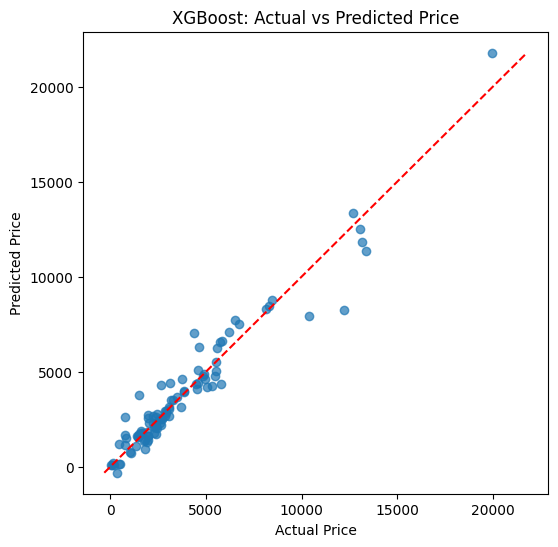

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_pred, alpha=0.7)

min_price = min(y_test.min(), xgb_pred.min())
max_price = max(y_test.max(), xgb_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--", color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Price")
plt.show()

### 3.2 Short conclusion
XGBoost achieved the best overall performance on the holdout test set, with the lowest MAE and RMSE and the highest R² among the three models. Therefore, XGBoost is selected as the main model for the following sanity check and feature importance analysis.

## 4. Sanity Check

Since XGBoost achieved the best performance, sanity checks were conducted to examine whether the high R² score was reasonable and stable.

### 4.1 Area-based sanity check

In [28]:
# Area-only baseline
area_cols = ["farea", "parea", "mb_area", "sb_area", "pu_area", "landa"]
existing_area_cols = [col for col in area_cols if col in df.columns]

X_area = df[existing_area_cols]
y_area = df["tprice"]

X_area_train, X_area_test, y_area_train, y_area_test = train_test_split(
    X_area,
    y_area,
    test_size=0.2,
    random_state=42
)

area_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

area_model.fit(X_area_train, y_area_train)
area_pred = area_model.predict(X_area_test)

In [29]:
# XGBoost without detailed area features
drop_area_detail = ["mb_area", "sb_area", "pu_area"]

X_less_area = X.drop(columns=[col for col in drop_area_detail if col in X.columns])

numeric_features_less = X_less_area.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_less = X_less_area.select_dtypes(include=["object"]).columns.tolist()

preprocessor_less = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_less),
        ("cat", categorical_transformer, categorical_features_less)
    ]
)

X_train_less, X_test_less, y_train_less, y_test_less = train_test_split(
    X_less_area,
    y,
    test_size=0.2,
    random_state=42
)

xgb_less_area = Pipeline(steps=[
    ("preprocess", preprocessor_less),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_less_area.fit(X_train_less, y_train_less)
less_area_pred = xgb_less_area.predict(X_test_less)

In [31]:
# Summary table
sanity_results = pd.DataFrame([
    {
        "Model": "Full XGBoost",
        "Description": "All features",
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
        "R2": r2_score(y_test, xgb_pred)
    },
    {
        "Model": "Area-only XGBoost",
        "Description": "Only area-related features",
        "MAE": mean_absolute_error(y_area_test, area_pred),
        "RMSE": np.sqrt(mean_squared_error(y_area_test, area_pred)),
        "R2": r2_score(y_area_test, area_pred)
    },
    {
        "Model": "XGBoost without detailed area",
        "Description": "Remove mb_area, sb_area, pu_area",
        "MAE": mean_absolute_error(y_test_less, less_area_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_less, less_area_pred)),
        "R2": r2_score(y_test_less, less_area_pred)
    },
    
])

sanity_results

,Model,Description,MAE,RMSE,R2
0,Full XGBoost,All features,571.359031,868.903690,0.933538
1,Area-only XGBoost,Only area-related features,823.966680,1390.937249,0.829688
2,XGBoost without detailed area,"Remove mb_area, sb_area, pu_area",612.182474,1109.766352,0.891584


### 4.2 Cross-validation stability check

In [30]:
cv_scores = cross_val_score(
    xgb_best,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": ["Mean R²", "Std R²"],
    "Value": [cv_scores.mean(), cv_scores.std()]
})

cv_summary

,Metric,Value
0,Mean R²,0.836524
1,Std R²,0.112308


### 4.3 Sanity check results

The area-only model achieved an R² of 0.830, showing that area-related variables explain a large portion of total transaction price.

After removing detailed area features (`mb_area`, `sb_area`, and `pu_area`), XGBoost still achieved an R² of 0.892. This suggests that the full model does not rely only on detailed area breakdown variables.

The 5-fold cross-validation result was used as an additional stability check for the XGBoost pipeline. The average R² was 0.837 with a standard deviation of 0.112, suggesting that the model remains reasonably predictive across different data splits, although the single test-set result may be optimistic.

## 5. Feature Importance

To interpret the best-performing model, permutation importance was used to evaluate how much each feature contributes to XGBoost prediction performance.

### 5.1 Feature importance experiment

In [19]:
perm_importance = permutation_importance(
    xgb_best,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
8,farea,1.038152
1,district,0.058505
0,case_t,0.033838
20,metro_in1500,0.026128
2,case_f,0.018681
18,metro_in500,0.009445
3,landa,0.007900
5,sbuild,0.006088
16,parea,0.003611
10,build_l,0.003532


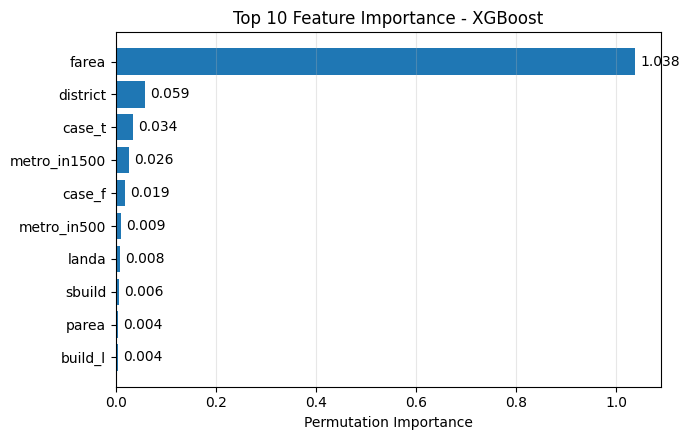

In [20]:
top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(7, 4.5))
bars = plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Permutation Importance")
plt.title("Top 10 Feature Importance - XGBoost")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Short conclusion

The feature importance result shows that `farea` is the dominant predictor of total transaction price. This is reasonable because the target variable is total price, and larger building area directly increases transaction value. Other features such as `district`, `case_t`, and nearby metro-related variables provide additional information, but their effects are much smaller than building area.